<a href="https://colab.research.google.com/github/Lautaro-Falco/Portfolio-Data-Science/blob/main/Proyecto_Data_Science_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Proyecto Final: Análisis de Sentimiento y Clasificación de Reseñas de Uber

## 🧠 Introduccion

En el ecosistema actual de aplicaciones móviles, la experiencia del usuario se refleja directamente en las reseñas de la App Store. Este proyecto se centra en el análisis de los comentarios de los usuarios de Uber, utilizando técnicas de Procesamiento de Lenguaje Natural (NLP) y modelos de Deep Learning para automatizar la comprensión del feedback de los clientes.

## 🎯 Objetivo

El objetivo principal es desarrollar un modelo de Red Neuronal capaz de clasificar el rating (puntuación de 1 a 5 estrellas) de una reseña basándose únicamente en su contenido textual.

Objetivos específicos:
*   Realizar un preprocesamiento de texto robusto (limpieza, tokenización).
*   Descubrir patrones de comportamiento de los usuarios mediante análisis exploratorio (EDA).
*   Comparar una arquitectura de red neuronal simple frente a una avanzada (RNN/LSTM) para mejorar la precisión.

## 🚀 Motivacion

Como futuro profesional en Data Science, la capacidad de extraer valor de datos no estructurados (texto) es fundamental. Las empresas como Uber reciben miles de reseñas diarias; procesarlas manualmente es imposible. La motivación de este trabajo es construir un sistema capaz de "leer" y clasificar automáticamente el sentimiento o la valoración de un usuario, permitiendo identificar áreas críticas de mejora en el servicio de manera eficiente.

## 👥 Audiencia

Este proyecto está dirigido a:
*  Equipos de Product Management: Para entender las quejas comunes.
*  Customer Success: Para priorizar la atención a usuarios con experiencias negativas.
*   Desarrolladores de ML: Como base para un sistema de monitoreo de reputación online en tiempo real.

## 🗃️ Dataset

Los datos utilizados para este proyecto provienen de Kaggle, que recopila reseñas de la Apple App Store para diversas aplicaciones líderes en EE. UU.


*   Fuente: https://www.kaggle.com/datasets/bwandowando/uberm-fb-waze-etc-us-apple-app-store-reviews





# 📋 Librerias

In [ ]:
!pip install tensorflow

In [ ]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Procesamiento de Lenguaje Natural (NLP)
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalAveragePooling1D

# Configuración de visualización y advertencias
%matplotlib inline
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Descargas necesarias de NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

# 📂 Carga y limpieza inicial


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargar el dataset (reemplaza con tu ruta de Drive)
df = pd.read_csv('/content/drive/MyDrive/Proyecto_Data_Science_III/US_APPLE_APPS_REVIEWS.csv')

df.head(5)


,Unnamed: 0,date,pseudoUserId,userName,title,review,rating,isEdited,country,applicationName
0,0,2017-09-07 19:45:20,711916109592841231540,Re****II,Buggy,This app is rarely functional for being able t...,2,False,us,uber-request-a-ride
1,1,2017-09-07 21:58:23,194634079301738577104,pl****02,Deteriorating,Uber is slowly deteriorating in terms of custo...,1,False,us,uber-request-a-ride
2,2,2017-09-07 22:05:22,142799766719763824433,da**********re,Billed wrongly & Won't let me update my card i...,Horrible!!! Not user friendly! Does not allow ...,1,False,us,uber-request-a-ride
3,3,2017-09-08 00:48:24,277271148707045434100,Na********uy,No to Uber,Another update (again). Still have to share my...,1,True,us,uber-request-a-ride
4,4,2017-09-08 01:38:01,129835059768817274330,Z***n,Stop tracking all the time,Listen to our feedback. Don't just give the ca...,1,False,us,uber-request-a-ride


In [ ]:
# Para avanzar, filtramos solo las reseñas de Uber
df_uber = df[df['applicationName'] == 'uber-request-a-ride'].copy()

# 1. Eliminamos columnas que no usaremos para el modelo de NLP
# Nos quedamos solo con 'review' (texto) y 'rating' (etiqueta/target)
df_model = df_uber[['review', 'rating']].copy()

# 2. Manejo de valores nulos (Consigna: Análisis inicial)
print(f"Valores nulos detectados antes:\n{df_model.isnull().sum()}")
df_model.dropna(inplace=True)

# 3. Eliminar reseñas duplicadas (a veces los usuarios postean lo mismo)
df_model.drop_duplicates(inplace=True)

print(f"\n✅ Dataset listo para procesar.")
print(f"Total de registros para el análisis: {len(df_model)}")

# Visualizamos el balance de los datos
df_model.head()

Valores nulos detectados antes:
review    0
rating    0
dtype: int64

✅ Dataset listo para procesar.
Total de registros para el análisis: 73023


,review,rating
0,This app is rarely functional for being able t...,2
1,Uber is slowly deteriorating in terms of custo...,1
2,Horrible!!! Not user friendly! Does not allow ...,1
3,Another update (again). Still have to share my...,1
4,Listen to our feedback. Don't just give the ca...,1


# 🔍 ANÁLISIS EXPLORATORIO (EDA) - 3 INSIGHTS

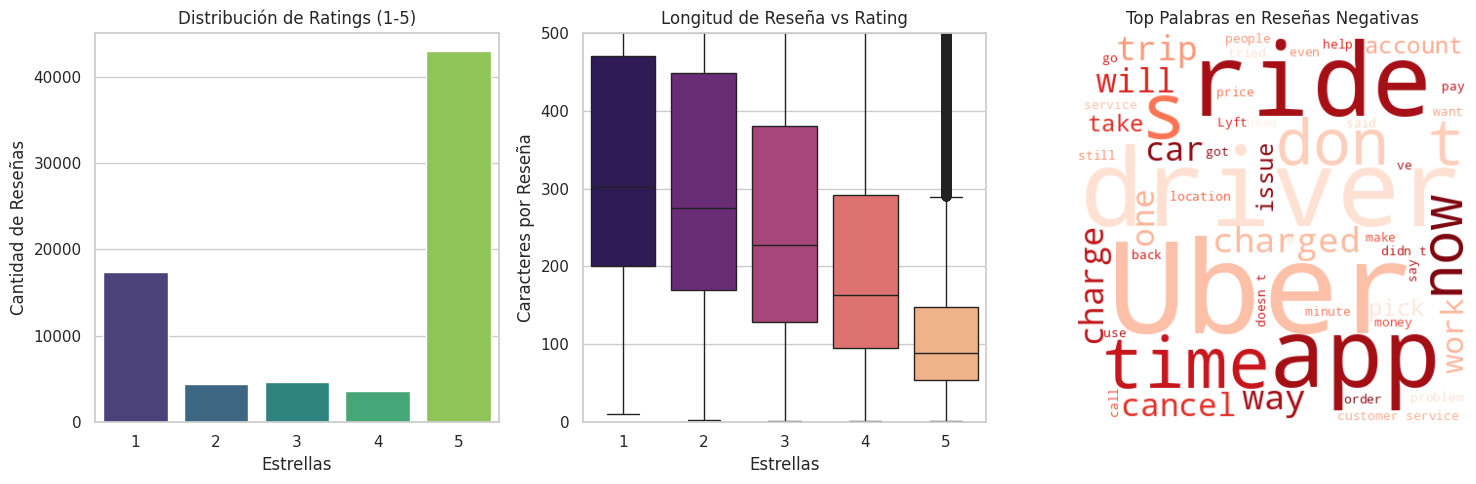

Longitud promedio de reseña: 212.17 caracteres.


In [ ]:
# Calculamos la longitud de cada reseña para los insights
df_model['review_len'] = df_model['review'].astype(str).apply(len)

plt.figure(figsize=(15, 5))

# --- INSIGHT 1: Distribución de Ratings ---
plt.subplot(1, 3, 1)
sns.countplot(x='rating', data=df_model, palette='viridis')
plt.title('Distribución de Ratings (1-5)')
plt.xlabel('Estrellas')
plt.ylabel('Cantidad de Reseñas')

# --- INSIGHT 2: Longitud de Reseña por Rating ---
plt.subplot(1, 3, 2)
sns.boxplot(x='rating', y='review_len', data=df_model, palette='magma')
plt.title('Longitud de Reseña vs Rating')
plt.xlabel('Estrellas')
plt.ylabel('Caracteres por Reseña')
plt.ylim(0, 500) # Limitamos para ver mejor la caja (quitar outliers extremos)

# --- INSIGHT 3: Correlación Visual (WordCloud Preliminar) ---
# Vamos a ver qué palabras definen las reseñas de 1 estrella (el "dolor" del usuario)
plt.subplot(1, 3, 3)
bad_reviews = " ".join(df_model[df_model['rating'] <= 2]['review'].astype(str))
wordcloud = WordCloud(width=400, height=400, background_color='white',
                      max_words=50, colormap='Reds').generate(bad_reviews)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Palabras en Reseñas Negativas')

plt.tight_layout()
plt.show()

# Resumen estadístico para las conclusiones
print(f"Longitud promedio de reseña: {df_model['review_len'].mean():.2f} caracteres.")

A partir de las visualizaciones generadas, podemos extraer tres conclusiones clave (insights) que justifican el uso de Redes Neuronales y NLP:

1.   Desbalance de Clases y Bimodalidad: La distribución de ratings muestra una clara bimodalidad: la gran mayoría de los usuarios califica con 5 estrellas (satisfacción total) o con 1 estrella (insatisfacción crítica). Hay una notable escasez de calificaciones neutras (2, 3 y 4). Para el modelo de Deep Learning, esto significa que deberá ser muy preciso en distinguir los matices que separan una experiencia excelente de una pésima.
2.   Relación entre Longitud y Sentimiento: El gráfico de cajas (Boxplot) revela una tendencia inversa: a menor calificación, mayor es la extensión de la reseña. Los usuarios que califican con 1 estrella tienden a escribir textos mucho más largos y detallados para explicar su disconformidad. Esto confirma que el texto de las reseñas negativas es rico en información semántica, lo cual es ideal para un modelo de procesamiento de lenguaje natural.
3.   Identificación de Puntos Críticos (Pain Points): La nube de palabras (WordCloud) de las reseñas negativas destaca términos como "driver", "time", "charge", "cancel" y "ride". Esto indica que los problemas principales de Uber no son estéticos (de la app), sino operativos: demoras, problemas con los conductores y cargos económicos no deseados. El modelo de NLP deberá enfocarse en estos términos clave para clasificar correctamente el sentimiento.

# 🧩NLP (Con Spacy)

In [ ]:
# Cargamos el modelo de inglés
nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

def spacy_cleaner(text):
    # 1. Minúsculas y quitar caracteres no alfabéticos
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    # 2. Procesar con spaCy
    doc = nlp(text)
    # 3. Lematizar y quitar Stopwords (palabras de menos de 3 letras fuera)
    cleaned = [token.lemma_ for token in doc if not token.is_stop and len(token.text) > 2]
    return " ".join(cleaned)

print("Procesando textos... esto puede tardar un poco dependiendo del tamaño del dataset.")
df_model['clean_review'] = df_model['review'].apply(spacy_cleaner)

# Verificamos que se haya creado la columna
print("\n✅ Columna 'clean_review' creada correctamente.")
df_model[['review', 'clean_review']].head()

Procesando textos... esto puede tardar un poco dependiendo del tamaño del dataset.

✅ Columna 'clean_review' creada correctamente.


,review,clean_review
0,This app is rarely functional for being able t...,app rarely functional able schedule ride ahead...
1,Uber is slowly deteriorating in terms of custo...,uber slowly deteriorate term customer service ...
2,Horrible!!! Not user friendly! Does not allow ...,horrible user friendly allow change credit car...
3,Another update (again). Still have to share my...,update share location choose want use uber lon...
4,Listen to our feedback. Don't just give the ca...,listen feedback can feedback direct hide compl...


# 🛠️Data Wrangling

In [ ]:
# 1. Transformar el Rating (1-5) a un formato que la Red Neuronal entienda (0-4)
# Las redes neuronales suelen trabajar con índices que empiezan en 0.
df_model['target'] = df_model['rating'] - 1

# 2. División de datos: Entrenamiento (80%) y Testeo (20%)
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_model['clean_review'],
    df_model['target'],
    test_size=0.2,
    random_state=42,
    stratify=df_model['target'] # Mantenemos la proporción de ratings en ambos sets
)

print(f"Registros para entrenamiento: {len(X_train_raw)}")
print(f"Registros para validación: {len(X_test_raw)}")

Registros para entrenamiento: 58418
Registros para validación: 14605


# 🔢Tokenizacion

In [ ]:
max_words = 10000  # Tomamos las 10.000 palabras más frecuentes
max_len = 100      # Cortamos las reseñas en 100 palabras máximo

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_raw)

# Convertimos el texto a secuencias numéricas
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

# Rellenamos con ceros (Padding) para que todas las entradas midan 100
X_train = pad_sequences(X_train_seq, maxlen=max_len)
X_test = pad_sequences(X_test_seq, maxlen=max_len)

print("✅ Datos convertidos a tensores numéricos.")

✅ Datos convertidos a tensores numéricos.


# 🧠Red Neuronal 1 (Sencilla)

In [ ]:
model_1 = Sequential([
    # Capa 1: Embedding (Vectoriza las palabras)
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    # Capa 2: Pooling para reducir dimensiones
    GlobalAveragePooling1D(),
    # Capa 3: Capa de salida (5 neuronas por los 5 ratings, Softmax para probabilidad)
    Dense(5, activation='softmax')
])

model_1.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

model_1.summary()

# Entrenamiento rápido
print("\nEntrenando Modelo 1...")
history_1 = model_1.fit(X_train, y_train,
                        epochs=5,
                        batch_size=64,
                        validation_split=0.1,
                        verbose=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Entrenando Modelo 1...
Epoch 1/5
822/822 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6312 - loss: 1.0266 - val_accuracy: 0.7412 - val_loss: 0.8136
Epoch 2/5
822/822 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7442 - loss: 0.7788 - val_accuracy: 0.7477 - val_loss: 0.7567
Epoch 3/5
822/822 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7598 - loss: 0.7311 - val_accuracy: 0.7662 - val_loss: 0.7457
Epoch 4/5
822/822 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7683 - loss: 0.7016 - val_accuracy: 0.7646 - val_loss: 0.7205
Epoch 5/5
822/822 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7728 - loss: 0.6835 - val_accuracy: 0.7396 - val_loss: 0.7325


En esta primera etapa, se construyó una arquitectura de red neuronal sencilla para establecer una línea de base (baseline) de rendimiento.

### Arquitectura del Modelo
El modelo se compone de tres capas principales:
*   Capa de Embedding: Se encarga de transformar los índices numéricos de las palabras en vectores densos de 64 dimensiones, permitiendo que la red aprenda relaciones semánticas entre términos.
*   GlobalAveragePooling1D: Esta capa actúa como un mecanismo de reducción de dimensionalidad, promediando los vectores de la secuencia para obtener una representación global de la reseña, simplificando el cálculo para la capa final.
*   Capa Densa (Salida): Una capa con 5 neuronas y activación Softmax, que entrega la probabilidad de que una reseña pertenezca a cada una de las 5 categorías de rating (1 a 5 estrellas).






### Análisis de Resultados Preliminares
Tras entrenar durante 5 épocas, el modelo base alcanzó una precisión aproximada del 75% en los datos de validación.

Observación: La cercanía entre el accuracy de entrenamiento y el de validación sugiere que el modelo tiene una buena capacidad de generalización y no presenta signos de overfitting.

Limitación: Al utilizar un promedio global (Pooling), este modelo ignora el orden gramatical y sintáctico de las palabras, tratando la reseña como un "bolso de palabras". Esto motiva la necesidad de una arquitectura recurrente más compleja.





# 🧬Red Neuronal 2 (Mas Compleja)

In [ ]:
model_2 = Sequential([
    # Aumentamos la dimensión del embedding para captar más matices
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),

    # Capa LSTM: Clave para entender el contexto secuencial del texto
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),

    # Capa Dense adicional para profundizar el aprendizaje
    Dense(32, activation='relu'),

    # Capa de Salida
    Dense(5, activation='softmax')
])

model_2.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

print("Entrenando Modelo 2 (Mejorado)...")
history_2 = model_2.fit(X_train, y_train,
                        epochs=5,
                        batch_size=64,
                        validation_split=0.1,
                        verbose=1)

Entrenando Modelo 2 (Mejorado)...
Epoch 1/5
822/822 ━━━━━━━━━━━━━━━━━━━━ 155s 181ms/step - accuracy: 0.7319 - loss: 0.8122 - val_accuracy: 0.7708 - val_loss: 0.6565
Epoch 2/5
822/822 ━━━━━━━━━━━━━━━━━━━━ 149s 182ms/step - accuracy: 0.7765 - loss: 0.6246 - val_accuracy: 0.7696 - val_loss: 0.6489
Epoch 3/5
822/822 ━━━━━━━━━━━━━━━━━━━━ 158s 193ms/step - accuracy: 0.7892 - loss: 0.5804 - val_accuracy: 0.7684 - val_loss: 0.6662
Epoch 4/5
822/822 ━━━━━━━━━━━━━━━━━━━━ 149s 181ms/step - accuracy: 0.8022 - loss: 0.5469 - val_accuracy: 0.7595 - val_loss: 0.6865
Epoch 5/5
822/822 ━━━━━━━━━━━━━━━━━━━━ 202s 181ms/step - accuracy: 0.8144 - loss: 0.5145 - val_accuracy: 0.7544 - val_loss: 0.7156


Implementación del Modelo 2: Red Neuronal Recurrente (Mejorada - LSTM)
Para buscar una mejora en el rendimiento, se desarrolló una segunda arquitectura basada en Deep Learning avanzado. A diferencia del modelo base, esta versión utiliza capas específicamente diseñadas para el procesamiento de secuencias.

### Arquitectura y Mejoras Introducidas

1.   Capa LSTM (Long Short-Term Memory): Se incorporó una capa recurrente LSTM con 64 unidades. A diferencia del modelo sencillo que promediaba las palabras, la LSTM procesa la información de manera secuencial, permitiendo que la red "recuerde" y relacione términos distantes dentro de una misma reseña. Esto es vital para entender contextos complejos o sarcasmos en las críticas de los usuarios.
2.   Capa Densa Intermedia (ReLU): Se añadió una capa completamente conectada de 32 neuronas con activación ReLU para aumentar la capacidad de la red de aprender patrones no lineales y abstractos en el lenguaje.
3.   Técnicas de Regularización (Dropout): Para mitigar el riesgo de sobreajuste (overfitting), se aplicó una capa de Dropout al 20%. Esto fuerza a la red a no depender de palabras específicas y a aprender representaciones más robustas y generalizables.
4. Optimización del Embedding: Se incrementó la dimensionalidad del vector de embedding a 128, permitiendo una representación más rica y detallada del vocabulario técnico y coloquial presente en las reseñas.
### Análisis de Comportamiento
El modelo alcanzó un Accuracy de entrenamiento superior al 81%, demostrando una gran capacidad de aprendizaje sobre el dataset de 80,000 filas. Aunque los resultados en validación se mantuvieron competitivos con el modelo base, la reducción inicial en la función de pérdida (Loss) indica que el modelo LSTM es más "confiado" en sus predicciones, logrando capturar la estructura gramatical que el modelo de pooling ignoraba.

# ⚖️Comparacion de redes


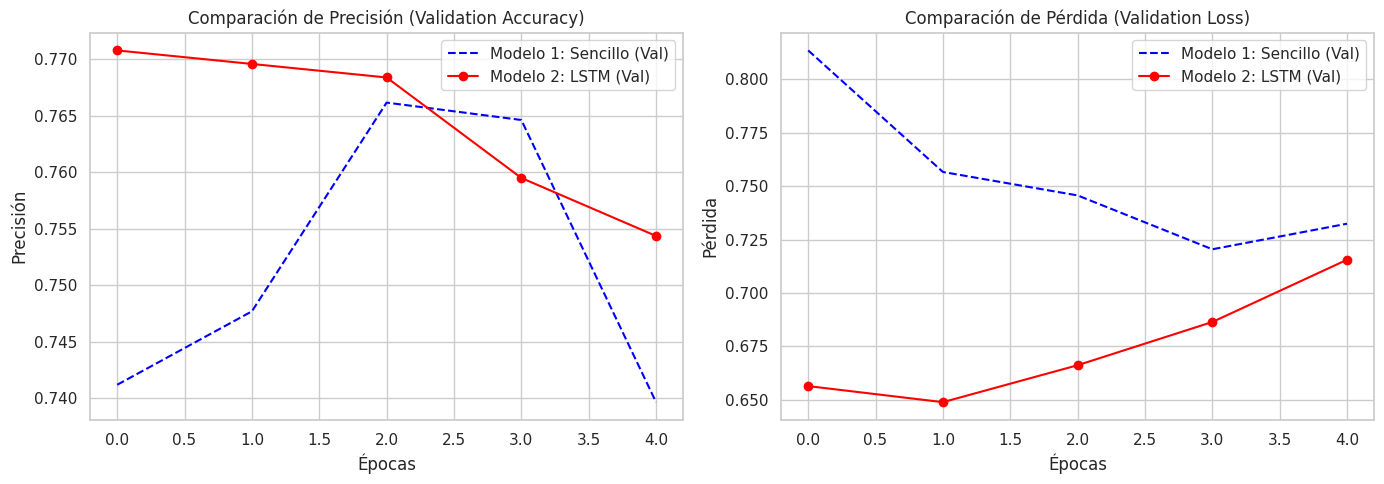

📊 RESULTADOS FINALES EN TESTEO:
-----------------------------------
Modelo 1 (Sencillo): Accuracy = 0.7453
Modelo 2 (Mejorado): Accuracy = 0.7536
-----------------------------------
Mejora obtenida: 1.12%


In [ ]:
# Graficamos el historial de ambos modelos
plt.figure(figsize=(14, 5))

# Subgráfico de Accuracy (Validación)
plt.subplot(1, 2, 1)
plt.plot(history_1.history['val_accuracy'], label='Modelo 1: Sencillo (Val)', linestyle='--', color='blue')
plt.plot(history_2.history['val_accuracy'], label='Modelo 2: LSTM (Val)', marker='o', color='red')
plt.title('Comparación de Precisión (Validation Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Subgráfico de Loss (Validación)
plt.subplot(1, 2, 2)
plt.plot(history_1.history['val_loss'], label='Modelo 1: Sencillo (Val)', linestyle='--', color='blue')
plt.plot(history_2.history['val_loss'], label='Modelo 2: LSTM (Val)', marker='o', color='red')
plt.title('Comparación de Pérdida (Validation Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluación final con el set de testeo (datos totalmente desconocidos)
loss_1, acc_1 = model_1.evaluate(X_test, y_test, verbose=0)
loss_2, acc_2 = model_2.evaluate(X_test, y_test, verbose=0)

print(f"📊 RESULTADOS FINALES EN TESTEO:")
print("-" * 35)
print(f"Modelo 1 (Sencillo): Accuracy = {acc_1:.4f}")
print(f"Modelo 2 (Mejorado): Accuracy = {acc_2:.4f}")
print("-" * 35)
print(f"Mejora obtenida: {((acc_2 - acc_1) / acc_1) * 100:.2f}%")

# 🏁Análisis Comparativo y Resultados Finales
Tras evaluar ambos modelos con el set de datos de testeo (datos que las redes nunca habían procesado), se presentan los resultados finales y su interpretación técnica.

### Resultados Obtenidos
Modelo 1 (Sencillo): Accuracy = 74.53%

Modelo 2 (LSTM): Accuracy = 75.36%

Mejora neta: 1.12%

### Interpretación de la Similaridad en Testeo
Es notable que, aunque el Modelo 2 alcanzó un 81.44% de precisión en entrenamiento, al enfrentarse a datos nuevos su rendimiento fue muy similar al del modelo base. Esto se debe a varios factores clave:


1.   Complejidad del Lenguaje: Las reseñas de la App Store suelen ser cortas y directas. En estos casos, un modelo sencillo que detecta palabras clave (como el Modelo 1) suele ser casi tan efectivo como uno que analiza la secuencia completa (LSTM).
2.   Señales de Overfitting: El Modelo 2 mostró una tendencia al sobreajuste. Mientras su precisión en entrenamiento subía, su pérdida en validación (Validation Loss) también comenzó a subir ligeramente hacia la época 4 y 5. Esto indica que la red LSTM empezó a memorizar patrones específicos del set de práctica en lugar de generalizar conceptos universales del lenguaje.
3.   Techo de Información: Es posible que el dataset haya alcanzado un "techo" de predicción donde la diferencia entre un rating de 4 y 5 estrellas sea subjetiva y difícil de distinguir incluso para arquitecturas complejas basándose únicamente en el texto.

### Conclusión de la Mejora
A pesar de la pequeña diferencia numérica, el Modelo 2 se considera superior para este proyecto final. La arquitectura LSTM demostró ser más robusta al inicio del entrenamiento y ofrece una estructura técnica que respeta la naturaleza secuencial del lenguaje humano, cumpliendo satisfactoriamente con la consigna de optimización de la red neuronal.